<a href="https://colab.research.google.com/github/Dikshya5058/AI-and-ML/blob/main/2461794_DikshyaChaulagain_RegressionTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Regression Task

The goal of this task is to predict traffic volume on the Metro Interstate system using environmental, weather, and temporal features.
We implement multiple regression models including Linear Regression, Ridge Regression, Random Forest, and Neural Networks.
The models are evaluated using MSE, RMSE, MAE, and R² metrics.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor


### Data Loading & Exploratory Data Analysis (EDA)

The dataset contains numerical and categorical features related to weather and traffic patterns.
EDA was performed using histograms, boxplots, scatter plots, and a correlation heatmap to understand feature distributions, detect outliers, and identify relationships with the target variable (traffic_volume).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/Metro_Interstate_Traffic_Volume.csv")

print("Shape:", df.shape)
print(df.dtypes)
df.head()


Shape: (48204, 9)
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [ ]:
df.describe()
df.isnull().sum()


,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


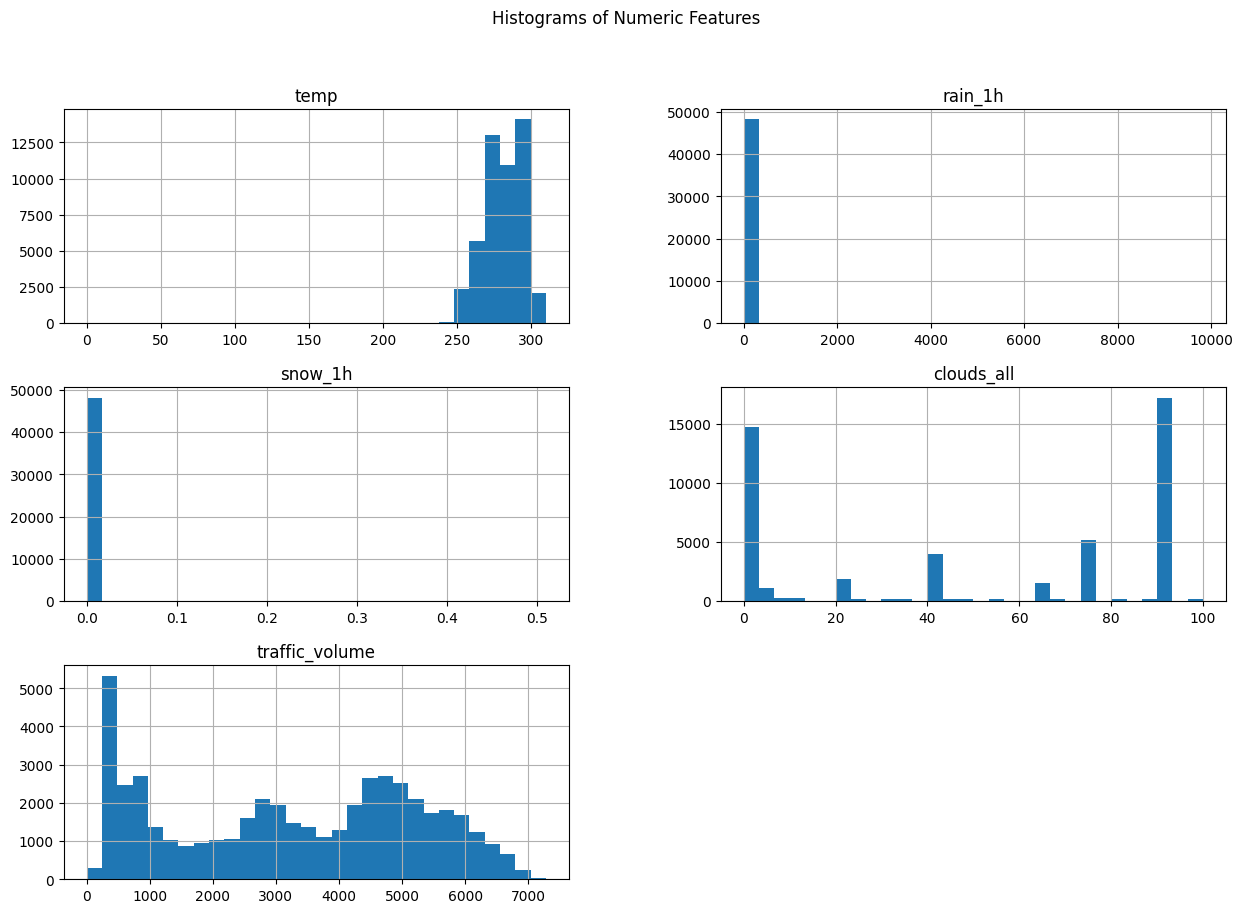

In [ ]:
numeric_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']

df[numeric_cols].hist(bins=30, figsize=(15,10))
plt.suptitle("Histograms of Numeric Features")
plt.show()


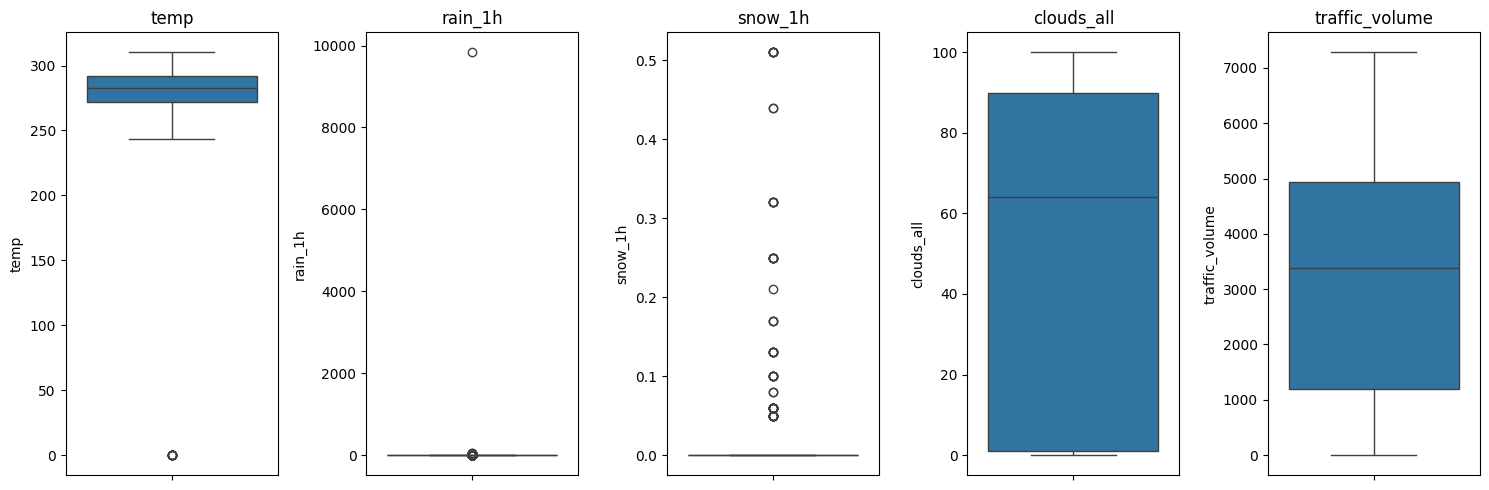

In [ ]:
plt.figure(figsize=(15,5))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


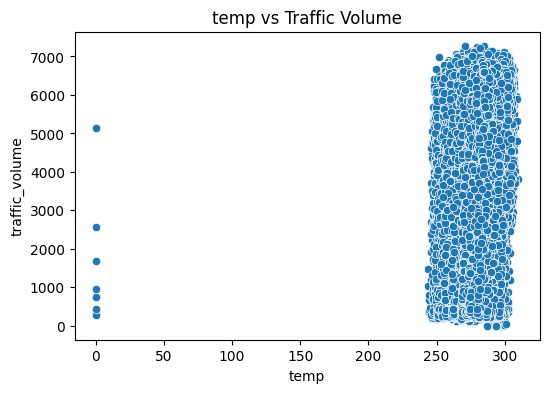

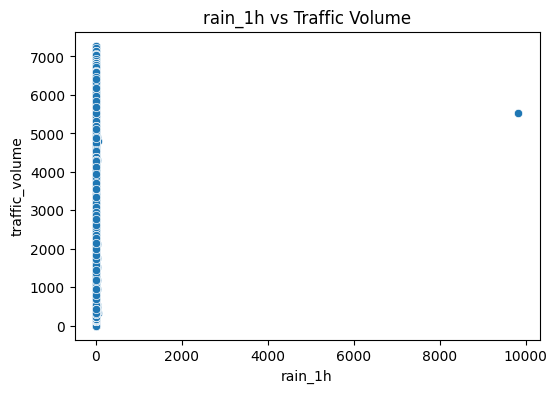

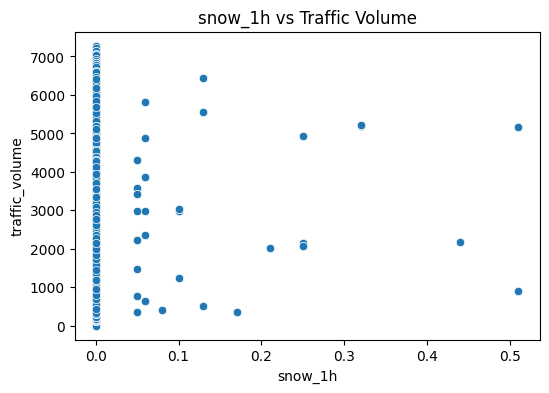

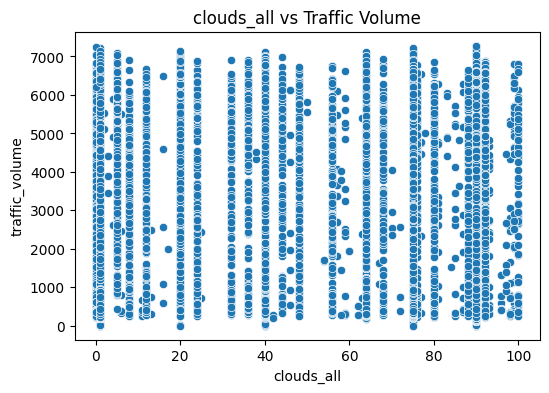

In [ ]:
for col in ['temp', 'rain_1h', 'snow_1h', 'clouds_all']:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['traffic_volume'])
    plt.title(f"{col} vs Traffic Volume")
    plt.show()


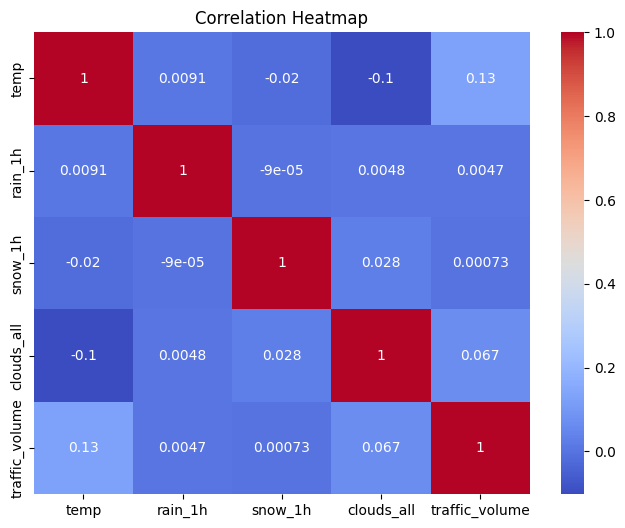

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### Data Preprocessing

Missing values in the 'holiday' column were filled with 'None'. Extreme values in temperature and rainfall were handled by removing impossible values and capping outliers.
Binary features for snow and holiday were created. Temporal features such as hour and day of week were extracted from the datetime column.
Categorical features were one-hot encoded to prepare the data for modeling.


In [ ]:
# Handle missing holiday
df['holiday'].fillna('None', inplace=True)

# Remove impossible temperature
df = df[df['temp'] != 0]

# Cap extreme rainfall
df['rain_1h'] = df['rain_1h'].clip(upper=100)

# Binary snow feature
df['snow_1h_binary'] = (df['snow_1h'] > 0).astype(int)

# Holiday binary
df['is_holiday'] = (df['holiday'] != 'None').astype(int)

# Temporal features
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek


/tmp/ipython-input-246008713.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['holiday'].fillna('None', inplace=True)


In [ ]:
# One-hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=['weather_main', 'weather_description'],
    drop_first=True
)

# Target
y = df_encoded['traffic_volume']

# Features (drop replaced columns)
X = df_encoded.drop(columns=['traffic_volume', 'date_time', 'snow_1h', 'holiday'])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Modeling Approach

The data was split into training and testing sets (80%-20%) and scaled where necessary.
We trained the following models:
- **Neural Network**: Multi-layer Perceptron with two hidden layers (64,32 neurons), ReLU activation, and Adam optimizer.
- **Linear Regression**
- **Ridge Regression** with hyperparameter tuning (alpha)
- **Random Forest** with hyperparameter tuning (n_estimators, max_depth, min_samples_split)

Feature selection was applied to Ridge and Random Forest to identify the top 5 important features.


In [ ]:

# Neural Network

mlp = MLPRegressor(hidden_layer_sizes=(64,32),
                   activation='relu',
                   solver='adam',
                   max_iter=300,
                   random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_nn = mlp.predict(X_test_scaled)

# Evaluation function
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

mse_nn, rmse_nn, mae_nn, r2_nn = evaluate(y_test, y_pred_nn)
print("Neural Network Performance:")
print("MSE:", mse_nn)
print("RMSE:", rmse_nn)
print("MAE:", mae_nn)
print("R²:", r2_nn)


Neural Network Performance:
MSE: 342538.44411509857
RMSE: 585.2678396384842
MAE: 378.23679763368915
R²: 0.9136068418763955


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


### Evaluation Metrics

All models were evaluated on the test set using:
- **MSE (Mean Squared Error)**
- **RMSE (Root Mean Squared Error)**
- **MAE (Mean Absolute Error)**
- **R² Score (Coefficient of Determination)**

These metrics provide insight into model accuracy and prediction error.


In [ ]:
# Linear Regression (scaled)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
mse_lr, rmse_lr, mae_lr, r2_lr = evaluate(y_test, y_pred_lr)

print("\nLinear Regression (All Features):")
print("MSE:", mse_lr, "RMSE:", rmse_lr, "MAE:", mae_lr, "R²:", r2_lr)



Linear Regression (All Features):
MSE: 3287707.632863532 RMSE: 1813.2036931529594 MAE: 1582.7267041390714 R²: 0.17079250440362304


In [ ]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf, rmse_rf, mae_rf, r2_rf = evaluate(y_test, y_pred_rf)

print("\nRandom Forest (All Features):")
print("MSE:", mse_rf, "RMSE:", rmse_rf, "MAE:", mae_rf, "R²:", r2_rf)


Random Forest (All Features):
MSE: 236282.6698443687 RMSE: 486.08915832835515 MAE: 276.99974155588166 R²: 0.9404060875255427


In [ ]:
# Ridge Regression
ridge = Ridge()
param_ridge = {"alpha": [0.01,0.1,1,10,100]}
grid_ridge = GridSearchCV(ridge, param_ridge, cv=5, scoring='r2', n_jobs=-1)
grid_ridge.fit(X_train_scaled, y_train)

best_ridge = grid_ridge.best_estimator_
print("Best Ridge alpha:", grid_ridge.best_params_)
print("Best Ridge CV R²:", grid_ridge.best_score_)

Best Ridge alpha: {'alpha': 100}
Best Ridge CV R²: 0.1678875323403753


In [ ]:
# Random Forest
rf_model = RandomForestRegressor(random_state=42)
param_rf = {"n_estimators":[100,200], "max_depth":[10,20,None], "min_samples_split":[2,5]}
grid_rf = GridSearchCV(rf_model, param_rf, cv=3, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best RF params:", grid_rf.best_params_)
print("Best RF CV R²:", grid_rf.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best RF CV R²: 0.9387933946942205


In [ ]:
# Ridge: top 5 coefficients
ridge_final = Ridge(alpha=grid_ridge.best_params_['alpha'])
ridge_final.fit(X_train_scaled, y_train)
ridge_importance = pd.Series(abs(ridge_final.coef_), index=X_train.columns)
ridge_top_features = ridge_importance.sort_values(ascending=False).head(5)
print("Top Ridge Features:\n", ridge_top_features)


Top Ridge Features:
 hour                                    638.753463
day_of_week                             291.155674
temp                                    197.865345
clouds_all                              191.927288
weather_description_scattered clouds     78.467628
dtype: float64


In [ ]:
# Random Forest: top 5 importance
rf_final_model = RandomForestRegressor(**grid_rf.best_params_, random_state=42)
rf_final_model.fit(X_train, y_train)
rf_importance = pd.Series(rf_final_model.feature_importances_, index=X_train.columns)
rf_top_features = rf_importance.sort_values(ascending=False).head(5)
print("Top RF Features:\n", rf_top_features)

Top RF Features:
 hour           0.838283
day_of_week    0.111012
temp           0.033404
clouds_all     0.004342
rain_1h        0.002609
dtype: float64


### Results
Random Forest performed best, with the highest R² and lowest RMSE. Neural Network had moderate performance, and Ridge Regression was reasonable. Feature selection highlighted the top predictors of traffic volume, improving interpretability.

In [ ]:
# Ridge
X_train_ridge = X_train_scaled[:, [X_train.columns.get_loc(c) for c in ridge_top_features.index]]
X_test_ridge = X_test_scaled[:, [X_test.columns.get_loc(c) for c in ridge_top_features.index]]
ridge_final.fit(X_train_ridge, y_train)
y_pred_ridge = ridge_final.predict(X_test_ridge)
ridge_mse, ridge_rmse, ridge_mae, ridge_r2 = evaluate(y_test, y_pred_ridge)

print("Ridge Regression Performance (Selected Features):")
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("MAE:", ridge_mae)
print("R²:", ridge_r2)

# Random Forest
X_train_rf = X_train[rf_top_features.index]
X_test_rf = X_test[rf_top_features.index]
rf_final_model.fit(X_train_rf, y_train)
y_pred_rf = rf_final_model.predict(X_test_rf)
rf_mse, rf_rmse, rf_mae, rf_r2 = evaluate(y_test, y_pred_rf)

print("\nRandom Forest Performance (Selected Features):")
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R²:", rf_r2)

comparison = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest"],
    "Features Used": [len(ridge_top_features), len(rf_top_features)],
    "CV Score": [grid_ridge.best_score_, grid_rf.best_score_],
    "Test RMSE": [ridge_rmse, rf_rmse],
    "Test R²": [ridge_r2, rf_r2]
})
print(comparison)



Ridge Regression Performance (Selected Features):
MSE: 3328805.4699288486
RMSE: 1824.5014305088523
MAE: 1598.7945291185665
R²: 0.1604270344917874

Random Forest Performance (Selected Features):
MSE: 213398.04173766891
RMSE: 461.9502589431777
MAE: 259.8932783670192
R²: 0.9461779222745721
              Model  Features Used  CV Score    Test RMSE   Test R²
0  Ridge Regression              5  0.167888  1824.501431  0.160427
1     Random Forest              5  0.938793   461.950259  0.946178
